[Datas](URL)
# About Dataset
### Context
This dataset is of casting manufacturing product.
Casting is a manufacturing process in which a liquid material is usually poured into a mould, which contains a hollow cavity of the desired shape, and then allowed to solidify.
Reason for collect this data is casting defects!!
Casting defect is an undesired irregularity in a metal casting process.
There are many types of defect in casting like blow holes, pinholes, burr, shrinkage defects, mould material defects, pouring metal defects, metallurgical defects, etc.
Defects are an unwanted thing in casting industry. For removing this defective product all industry have their quality inspection department. But the main problem is this inspection process is carried out manually. It is a very time-consuming process and due to human accuracy, this is not 100% accurate. This can because of the rejection of the whole order. So it creates a big loss in the company.

We decided to make the inspection process automatic and for this, we need to make deep learning classification model for this problem.

### contain
These all photos are top view of submersible pump impeller(google search for better understanding).
The dataset contains total 7348 image data. These all are the size of (300*300) pixels grey-scaled images. In all images, augmentation already applied.

Also uploaded images size of 512x512 grayscale. This data set is without Augmentation. This contains 519 ok_front and 781 def_front impeller images.

For capturing these images requires stable lighting, for this we made a special arrangement.

there are mainly two categories:-
1) Defective
2)Ok

making classification model we already split data for training and testing into two folders.
Both train and test folder contains def_front and ok_front subfolders.

train:- def_front have 3758 and ok_front have 2875 images
test:- def_front have:- def_front have 453 and ok_front have 262 images

In [1]:
import os
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Image Loading with Labels

In [2]:
def load_image_paths(root_dir):
    classes = ['def_front', 'ok_front']
    image_paths = []
    labels = []

    for idx, cls in enumerate(classes):
        class_dir = os.path.join(root_dir, cls)

        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)

            if img_name.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tiff")):
                image_paths.append(img_path)
                labels.append(idx)

    return image_paths, labels

# Train and Validation Split
- 80% Train
- 20% Validation

In [3]:
root_dir = r"C:\Users\Abdullah\__torch\Datasets\archive_4\casting_data\casting_data\train"

image_paths, labels = load_image_paths(root_dir)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(len(train_paths))

5306


In [4]:
print(os.listdir(root_dir))

['def_front', 'ok_front']


# Image Augmentation 

In [5]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [6]:
imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std  = (0.229, 0.224, 0.225)

In [7]:
train_transform = A.Compose([
    
    A.Resize(224, 224),

    # geometric augmentations
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=20,
        p=0.7
    ),

    # image quality / lighting variation
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.2),

    # slight blur/noise (helps generalization)
    A.GaussianBlur(p=0.1),
    A.GaussNoise(p=0.2),

    # normalize for ResNet50 pretrained weights
    A.Normalize(mean=imagenet_mean, std=imagenet_std),

    ToTensorV2()
])

C:\Users\Abdullah\anaconda3\envs\cvpr\lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [8]:
val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=imagenet_mean, std=imagenet_std),
    ToTensorV2()
])

# Dataset & DataLoader Class

In [9]:
class MyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
    
        image = Image.open(img_path).convert("RGB")
        image = np.array(image)
    
        if self.transform:
            image = self.transform(image=image)   
            image = image["image"]
    
        return image, torch.tensor(label, dtype=torch.long)

In [10]:
train_dataset = MyDataset(train_paths, train_labels, transform=train_transform)
val_dataset = MyDataset(val_paths, val_labels, transform=val_transform)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

# CBAM Block

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [13]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))

        out = avg_out + max_out
        return self.sigmoid(out)

In [14]:
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)

        return self.sigmoid(x)

In [15]:
class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, kernel_size=7):
        super().__init__()

        self.channel_attention = ChannelAttention(channels, reduction)
        self.spatial_attention = SpatialAttention(kernel_size)

    def forward(self, x):
        x = x * self.channel_attention(x)
        x = x * self.spatial_attention(x)
        return x

# Pretrained ResNet50 with CBAM

In [ ]:
import torchvision.models as models

class ResNet50_CBAM(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        resnet = models.resnet50(pretrained=pretrained)

        # Backbone layers
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool

        self.layer1 = resnet.layer1
        self.cbam1 = CBAM(256)

        self.layer2 = resnet.layer2
        self.cbam2 = CBAM(512)

        self.layer3 = resnet.layer3
        self.cbam3 = CBAM(1024)

        self.layer4 = resnet.layer4
        self.cbam4 = CBAM(2048)

        # Classification head
        self.avgpool = resnet.avgpool
        self.fc = nn.Sequential(
                    nn.Linear(2048, 1024),
                    nn.ReLU(inplace=True),
                    nn.Dropout(p=0.5),
                
                    nn.Linear(1024, 512),
                    nn.ReLU(inplace=True),
                    nn.Dropout(p=0.3),

                    nn.Linear(512, 256),
                    nn.ReLU(inplace=True),
                    nn.Dropout(p=0.4),
                
                    nn.Linear(256, num_classes)
        )
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.cbam1(x)

        x = self.layer2(x)
        x = self.cbam2(x)

        x = self.layer3(x)
        x = self.cbam3(x)

        x = self.layer4(x)
        x = self.cbam4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet50_CBAM(num_classes=2).to(device)

C:\Users\Abdullah\anaconda3\envs\cvpr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Abdullah\anaconda3\envs\cvpr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [18]:
backbone_params = []
fc_params = []

for name, param in model.named_parameters():
    if "fc" in name:
        fc_params.append(param)
    else:
        backbone_params.append(param)

In [19]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 1e-4},   # low LR for pretrained layers
    {"params": fc_params, "lr": 1e-3}          # higher LR for classifier
], weight_decay=1e-4)

In [20]:
import torch
import numpy as np
import copy

In [21]:
def accuracy_fn(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    return correct / labels.size(0)

# Single Epoch Training and Validation Function

In [22]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0
    total_acc = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += accuracy_fn(outputs, labels)

    return total_loss / len(loader), total_acc / len(loader)

In [23]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    total_acc = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item()
        total_acc += accuracy_fn(outputs, labels)

    return total_loss / len(loader), total_acc / len(loader)

# Training Function

In [24]:
def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=50,
    patience=7,
    save_path="defect_models/best_model.pth"
):
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_loss = float("inf")
    best_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )

        val_loss, val_acc = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Save history (like TensorFlow)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # TensorFlow-like logs
        print(f"Epoch [{epoch+1}/{epochs}]")
        print(f" - loss: {train_loss:.4f} - acc: {train_acc:.4f}")
        print(f" - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

        # Save best model
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            print("Best model saved")

            patience_counter = 0
        else:
            patience_counter += 1

        # Early stopping
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

    # Load best model at end
    model.load_state_dict(best_weights)

    # Save final model
    torch.save(model.state_dict(), "last_model.pth")

    return model, history

# Calling the training function

In [25]:
os.makedirs("defect_models", exist_ok=True)

model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=50,
    patience=7,
    save_path="defect_models/best_resnet50_cbam.pth"
)

Epoch [1/50]
 - loss: 0.2395 - acc: 0.8804
 - val_loss: 0.0302 - val_acc: 0.9940
Best model saved
Epoch [2/50]
 - loss: 0.1488 - acc: 0.9330
 - val_loss: 0.0430 - val_acc: 0.9948
Epoch [3/50]
 - loss: 0.0944 - acc: 0.9661
 - val_loss: 0.0161 - val_acc: 0.9955
Best model saved
Epoch [4/50]
 - loss: 0.0899 - acc: 0.9668
 - val_loss: 0.0346 - val_acc: 0.9933
Epoch [5/50]
 - loss: 0.0738 - acc: 0.9740
 - val_loss: 0.0194 - val_acc: 0.9955
Epoch [6/50]
 - loss: 0.0634 - acc: 0.9770
 - val_loss: 0.0189 - val_acc: 0.9955
Epoch [7/50]
 - loss: 0.0672 - acc: 0.9740
 - val_loss: 0.0168 - val_acc: 0.9955
Epoch [8/50]
 - loss: 0.0726 - acc: 0.9776
 - val_loss: 0.0165 - val_acc: 0.9955
Epoch [9/50]
 - loss: 0.0522 - acc: 0.9821
 - val_loss: 0.0149 - val_acc: 0.9955
Best model saved
Epoch [10/50]
 - loss: 0.0413 - acc: 0.9864
 - val_loss: 0.0169 - val_acc: 0.9955
Epoch [11/50]
 - loss: 0.0471 - acc: 0.9834
 - val_loss: 0.0123 - val_acc: 0.9955
Best model saved


KeyboardInterrupt: 

# Graphs for the training

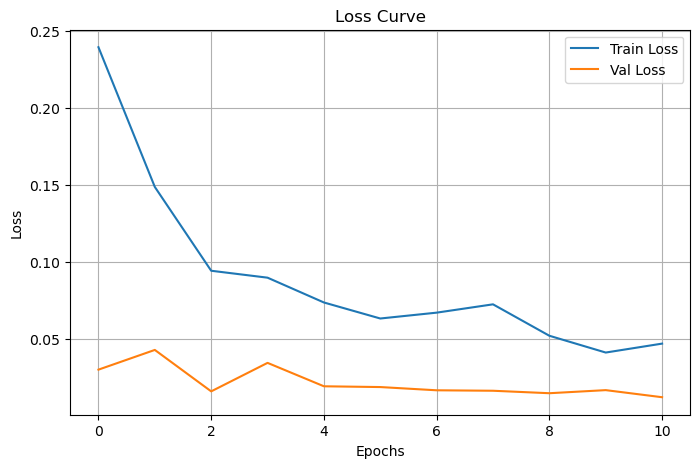

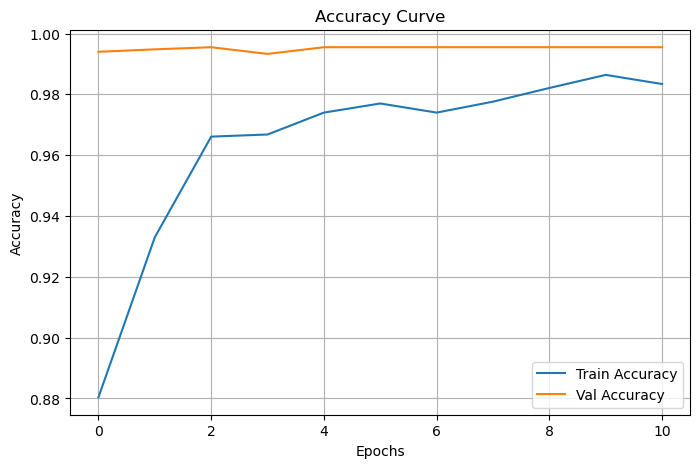

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")

plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))

plt.plot(history["acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Val Accuracy")

plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Reloading The Model

In [26]:
model = ResNet50_CBAM(num_classes=2).to(device)

model.load_state_dict(
    torch.load("defect_models/best_resnet50_cbam.pth", map_location=device)
)

model.eval()

C:\Users\Abdullah\anaconda3\envs\cvpr\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Abdullah\anaconda3\envs\cvpr\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\Abdullah\AppData\Local\Temp\ipykernel_11936\270110568.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pyto

ResNet50_CBAM(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stri

In [27]:
test_root = r"C:\Users\Abdullah\__torch\Datasets\archive_4\casting_data\casting_data\test"

test_paths, test_labels = load_image_paths(test_root)

In [28]:
test_dataset = MyDataset(
    test_paths,
    test_labels,
    transform=val_transform  
)

In [29]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = correct / total
    avg_loss = total_loss / len(loader)

    return avg_loss, acc, all_preds, all_labels

In [31]:
test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Test Loss and Accuracy Score

In [32]:
test_loss, test_acc, y_pred, y_true = evaluate(
    model, test_loader, criterion, device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Loss: 0.0097
Test Accuracy: 0.9972


In [56]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Confusion Matrix

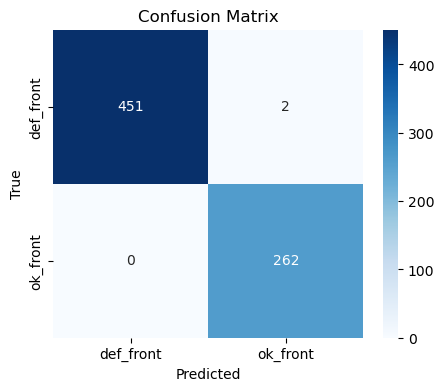

In [57]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["def_front", "ok_front"],
            yticklabels=["def_front", "ok_front"])

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [35]:
print(classification_report(
    y_true,
    y_pred,
    target_names=["def_front", "ok_front"]
))

              precision    recall  f1-score   support

   def_front       1.00      1.00      1.00       453
    ok_front       0.99      1.00      1.00       262

    accuracy                           1.00       715
   macro avg       1.00      1.00      1.00       715
weighted avg       1.00      1.00      1.00       715



# Random Predictions

In [36]:
import random
import numpy as np

def show_predictions(model, dataset, num=6):
    model.eval()

    indices = random.sample(range(len(dataset)), num)

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]

        with torch.no_grad():
            output = model(image.unsqueeze(0).to(device))
            pred = torch.argmax(output, 1).item()

        img = image.permute(1, 2, 0).cpu().numpy()

        plt.subplot(2, 3, i+1)
        plt.imshow(img)

        color = "green" if pred == label else "red"
        plt.title(f"True: {label} | Pred: {pred}", color=color)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


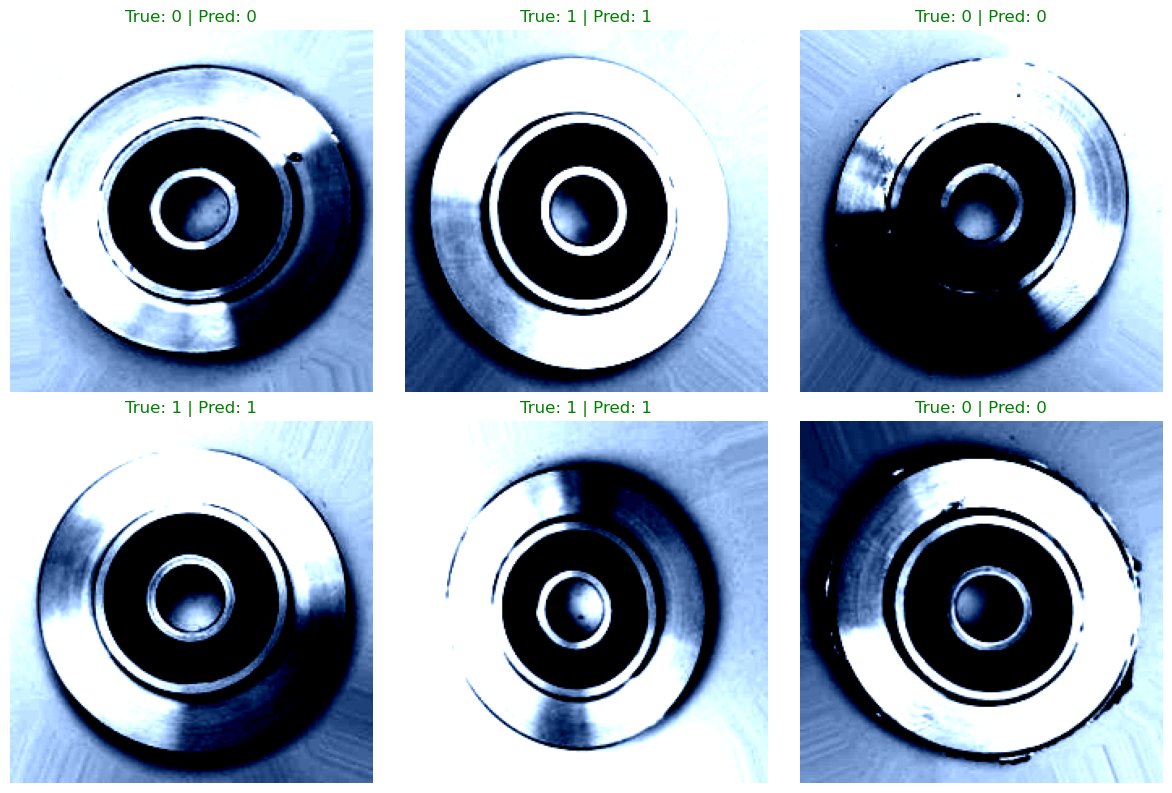

In [37]:
show_predictions(model, test_dataset, num=6)

# GradCam XAI

In [38]:
model.layer4[-1]

Bottleneck(
  (conv1): Conv2d(2048, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(512, 2048, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (bn3): BatchNorm2d(2048, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
)

In [43]:
import cv2

In [44]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer

        self.gradients = None
        self.activations = None

        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output

        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0]

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_backward_hook(backward_hook)

    def generate_cam(self, input_tensor, class_idx=None):
        self.model.eval()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        self.model.zero_grad()
        output[0, class_idx].backward()

        # Get gradients + activations
        grads = self.gradients[0]       # [C, H, W]
        acts = self.activations[0]      # [C, H, W]

        # Global average pooling on gradients
        weights = torch.mean(grads, dim=(1, 2))

        cam = torch.zeros(acts.shape[1:], device=input_tensor.device)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().detach().numpy(), class_idx

In [45]:
def overlay_cam(img, cam, alpha=0.4):
    img = img.permute(1, 2, 0).cpu().numpy()

    img = (img * 255).astype(np.uint8)

    cam = cv2.resize(cam, (img.shape[1], img.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

    return overlay

In [46]:
def show_gradcam(model, dataset, device, num=6):
    model.eval()

    cam_extractor = GradCAM(model, model.layer4[-1])

    indices = np.random.choice(len(dataset), num, replace=False)

    plt.figure(figsize=(12, 8))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        cam, pred = cam_extractor.generate_cam(input_tensor)

        overlay = overlay_cam(image, cam)

        plt.subplot(2, 3, i+1)
        plt.imshow(overlay)
        plt.title(f"True: {label} | Pred: {pred}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# For each image:

### 🔵 heatmap = model attention
### 🟢 green = correct prediction
### 🔴 red = wrong prediction

C:\Users\Abdullah\anaconda3\envs\cvpr\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


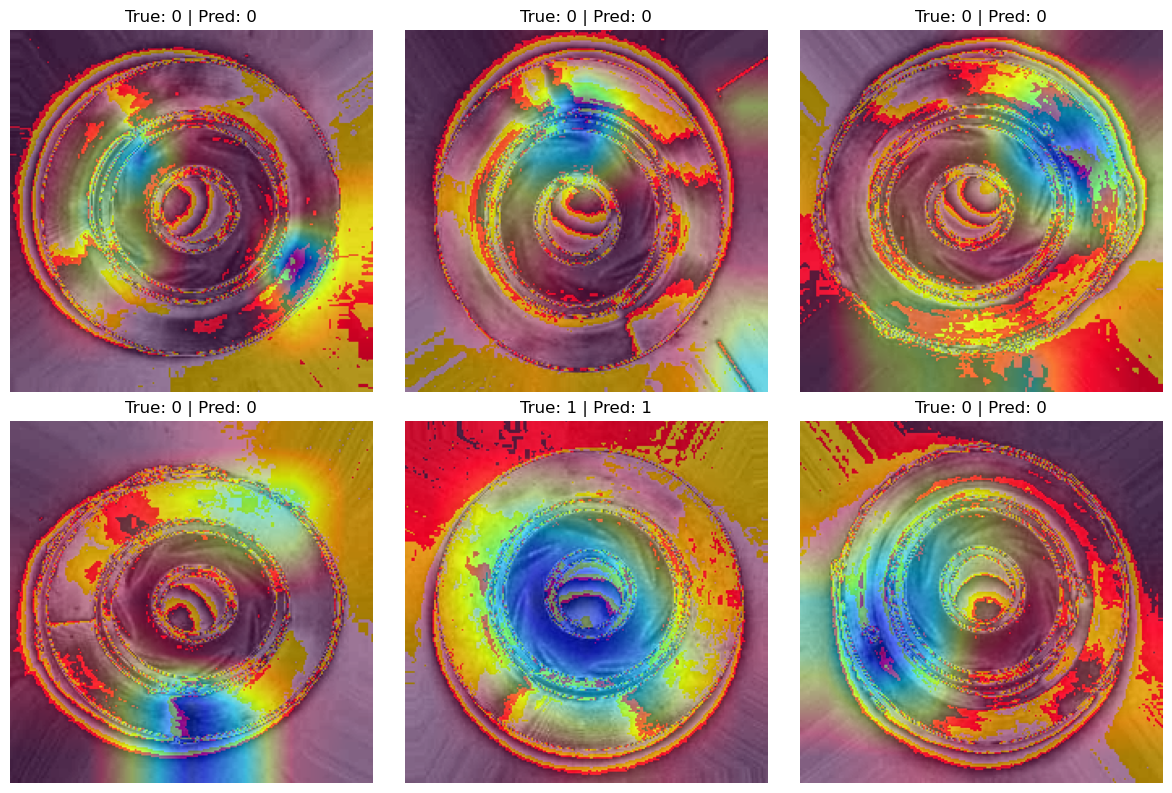

In [49]:
show_gradcam(model, test_dataset, device, num= 6)